  <h1><b> PROJECT: CUSTOMER CHURN ANALYSIS & PREDICTION</h1>

Churn = Customer loss.
Churn prediction is the process of using data to identify which customers are likely to leave in the future.

Churn = Yes → Likely to leave

Churn = No → Likely to stay


In [ ]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')



### **Dataset Overview:**

In [ ]:
print (f"The dataset has {df.shape[0]} rows  and {df.shape[1]} columns")

The dataset has 7043 rows  and 21 columns


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].mean(),inplace=True)

/tmp/ipython-input-84182948.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(),inplace=True)


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2265.000258
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# **EDA**

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
custom_palette = ["#0072B2","#D55E00"]

sns.set_theme(style="whitegrid", palette=custom_palette)

## **Bivariate Analysis**

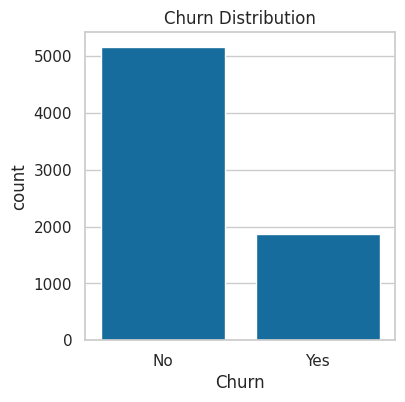

In [ ]:
plt.figure(figsize=(4, 4))
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.show()



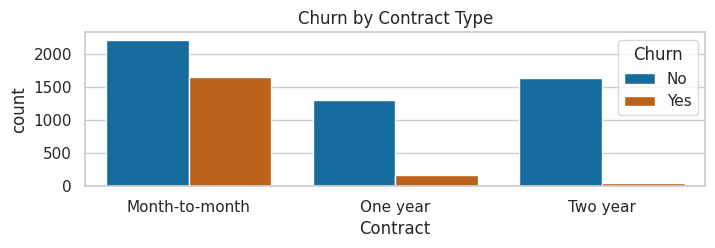

In [ ]:
plt.figure(figsize=(8,2))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.show()


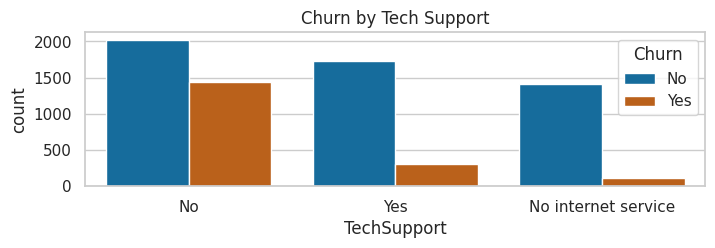

In [ ]:
#churn by tech support
plt.figure(figsize=(8,2))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title("Churn by Tech Support")
plt.show()

In [ ]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


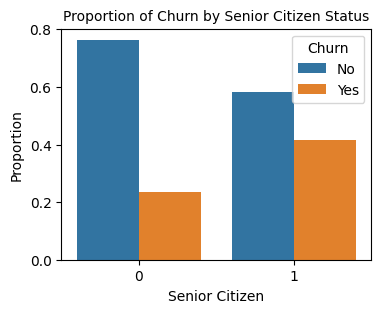

In [ ]:
plt.figure(figsize=(4,3))
prop_df = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).rename('proportion').reset_index()
sns.barplot(x='SeniorCitizen', y='proportion', hue='Churn', data=prop_df)
plt.ylabel("Proportion")
plt.xlabel("Senior Citizen")
plt.title("Proportion of Churn by Senior Citizen Status", fontsize=10)
plt.legend(title='Churn')
plt.show()


The Risk: In the '1' (senior) group, the bars are almost equal, meaning nearly half of all senior customers in this dataset churned.

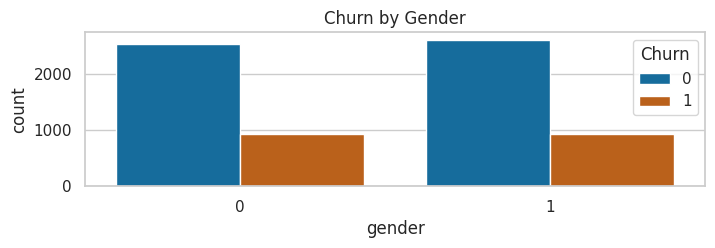

In [ ]:
#gender wise churn
plt.figure(figsize=(8,2))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title("Churn by Gender")
plt.xticks(rotation=0)
plt.show()

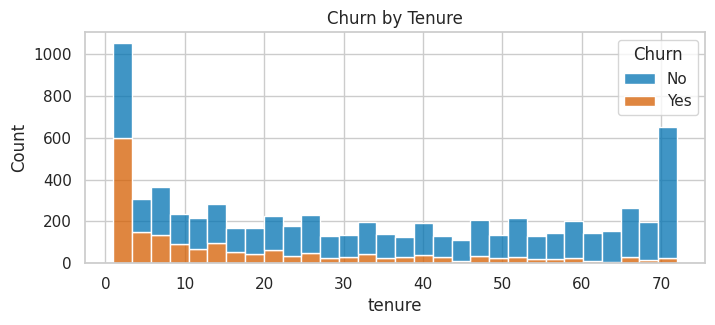

In [ ]:
plt.figure(figsize=(8,3))
sns.histplot(df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title("Churn by Tenure")
plt.show()


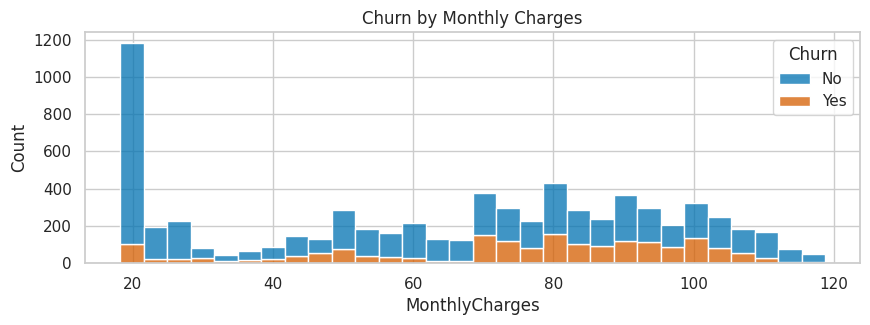

In [ ]:
#monthly charges vs churn
plt.figure(figsize=(10,3))
sns.histplot(df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30)
plt.title("Churn by Monthly Charges")
plt.show()

High Charges = High Churn Risk

Low Charges = High Stability

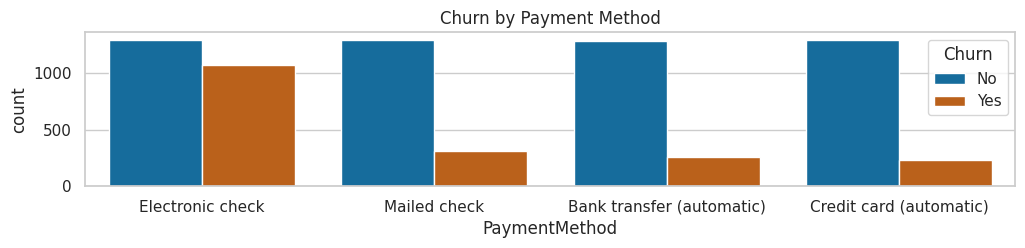

In [ ]:
#payment method vs churn
plt.figure(figsize=(12,2))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title("Churn by Payment Method")
plt.xticks(rotation=0)
plt.show()

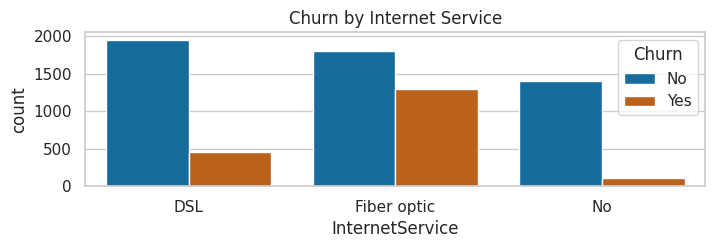

In [ ]:
#internet service vs churn
plt.figure(figsize=(8,2))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Churn by Internet Service")
plt.xticks(rotation=0)
plt.show()

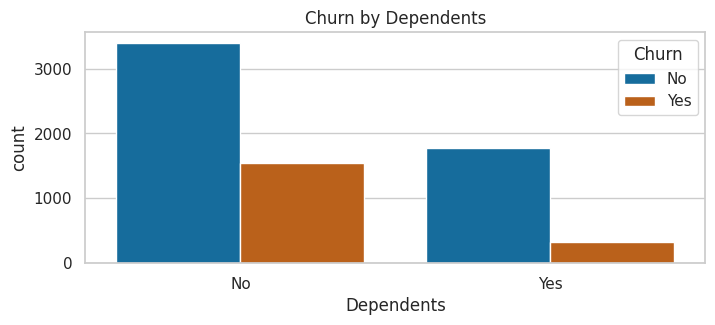

In [ ]:
#churn vs dependents
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.title("Churn by Dependents")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Internet-related columns
internet_cols = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')

# Phone-related column
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [ ]:
import numpy  as np
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn','MultipleLines','OnlineBackup','DeviceProtection',
    'TechSupport']
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map(binary_map)


## **ChiSquare Test:**

In [ ]:
#wether there exists a relation between churn and other categorical variables
from scipy.stats import chi2_contingency
import pandas as pd
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService','OnlineSecurity',
    'OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies','Contract', 'PaperlessBilling', 'PaymentMethod'
]
chi_results = []
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi_results.append({
        'Feature': col,
        'Chi-Square': chi2,
        'p-value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results).sort_values(by='p-value')
chi_df


,Feature,Chi-Square,p-value,Significant
13,Contract,1184.596572,5.863038e-258,Yes
6,InternetService,732.309590,9.571788e-160,Yes
15,PaymentMethod,648.142327,3.682355e-140,Yes
14,PaperlessBilling,258.277649,4.073355e-58,Yes
7,OnlineSecurity,205.633104,1.232098e-46,Yes
10,TechSupport,190.166842,2.923567e-43,Yes
3,Dependents,189.129249,4.924922e-43,Yes
1,SeniorCitizen,159.426300,1.510067e-36,Yes
2,Partner,158.733382,2.139911e-36,Yes
8,OnlineBackup,47.260854,6.214093e-12,Yes


## **Features Correlation Analysis**

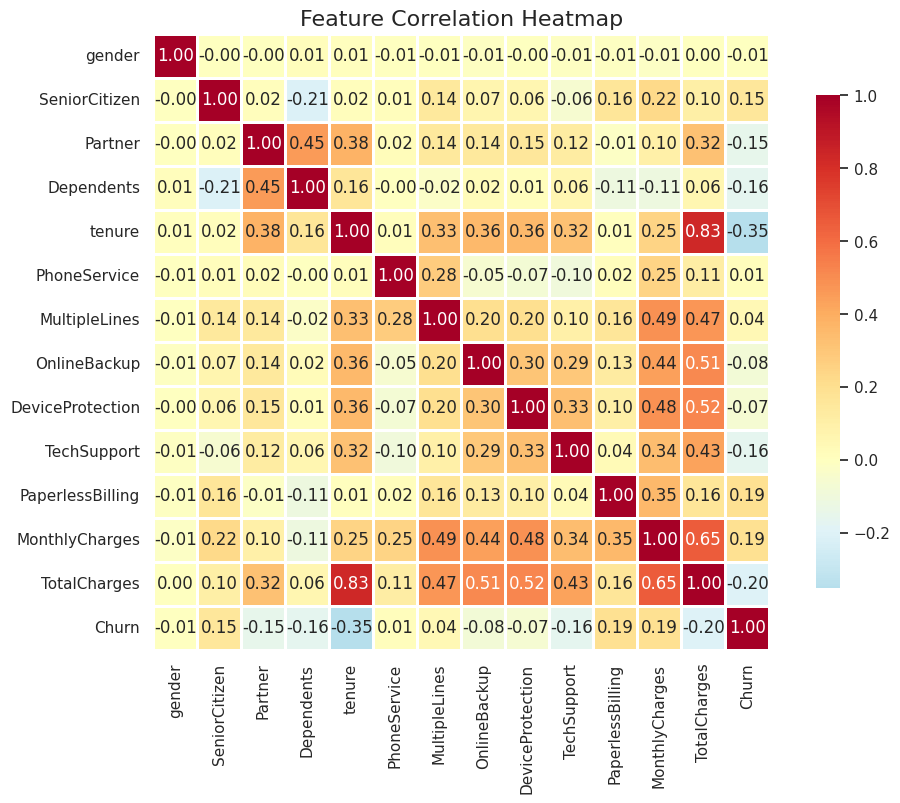

In [ ]:

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0,
            square=True, linewidths=1, cbar_kws={"shrink":0.8})
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

Both statistical methods independently confirm that gender and phone service have no meaningful relationship with customer churn.


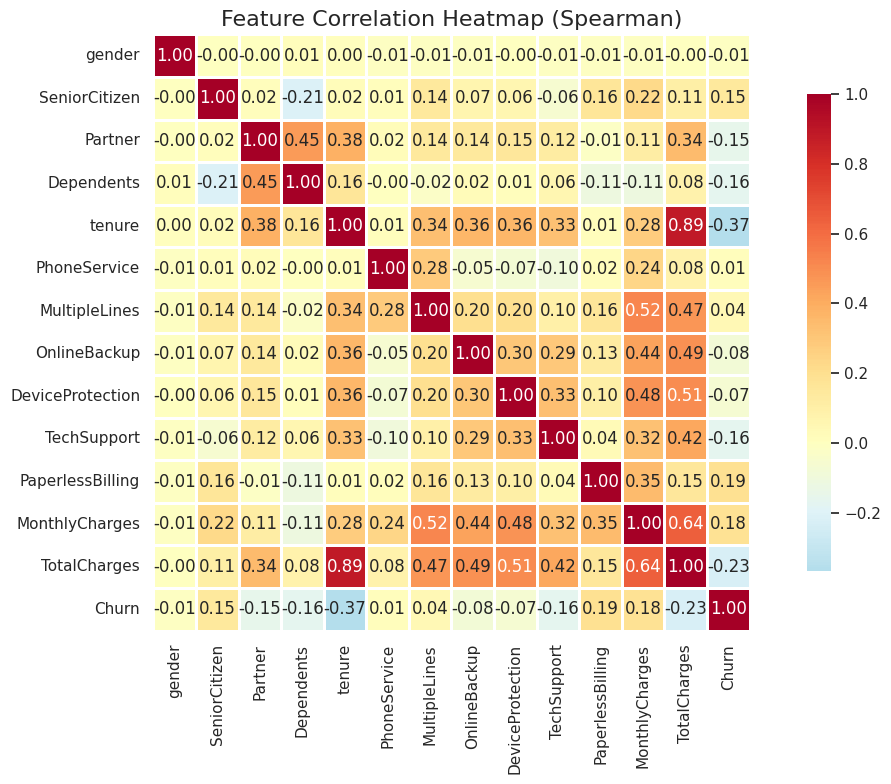

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Spearman correlation
corr_matrix = df[numeric_cols].corr(method='spearman')
# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap (Spearman)", fontsize=16)
plt.tight_layout()
plt.show()


Pearson and Spearman correlations produced nearly identical values, this indicates that the relationships between features and churn are largely linear as well as monotonic.